In [1]:
#import dependencies
import pandas as pd
import sqlite3

In [2]:
#create a sqlite3 file
db_name = "opioid_analysis.sqlite"

conn = sqlite3.connect(db_name)
cursor = conn.cursor()

In [3]:
#read our cleaned data csv
df = pd.read_csv("CT_OpioidData_Final.csv")
df.head()

,IncidentID,DateReported,Sex,Race,Age,InjuryPlace,InjuryCity,InjuryCounty,InjuryState,InjuryZip,...,Hydrocodone,Benzodiazepines,Methadone,Meth/Amphetamine,Tramadol,Hydromorphone,Morphine (not heroin),Other,Unnamed: 25,Unnamed: 26
0,1,1/1/19,Male,White,58,Residence,Bridgeport,Fairfield,CT,6604,...,0,0,0,0,0,0,0,0,NaN,NaN
1,2,1/1/19,Male,Black or African American,22,"Other, Residential Institution",Norwalk,Fairfield,CT,6854,...,0,1,0,0,0,0,0,1,NaN,NaN
2,3,1/1/19,Male,"Hispanic, White",60,Residence,Waterbury,New Haven,CT,6708,...,0,0,0,0,0,1,0,0,NaN,NaN
3,4,1/1/19,Male,"Hispanic, White",33,Residence,Meriden,New Haven,CT,6450,...,0,0,0,0,0,0,0,0,NaN,NaN
4,5,1/2/19,Male,White,24,Residence,Glastonbury,Hartford,CT,6033,...,0,1,0,0,0,0,0,0,NaN,NaN


In [4]:
df.to_sql("ct_opioiddata_final", conn, if_exists="replace", index=False)

7681

In [5]:
#query to make sure we imported and created it properly
query = "SELECT * FROM ct_opioiddata_final LIMIT 5;"
result = pd.read_sql(query, conn)
print(result)

   IncidentID DateReported   Sex                       Race  Age  \
0           1       1/1/19  Male                      White   58   
1           2       1/1/19  Male  Black or African American   22   
2           3       1/1/19  Male            Hispanic, White   60   
3           4       1/1/19  Male            Hispanic, White   33   
4           5       1/2/19  Male                      White   24   

                      InjuryPlace   InjuryCity InjuryCounty InjuryState  \
0                       Residence   Bridgeport    Fairfield          CT   
1  Other, Residential Institution      Norwalk    Fairfield          CT   
2                       Residence    Waterbury    New Haven          CT   
3                       Residence      Meriden    New Haven          CT   
4                       Residence  Glastonbury     Hartford          CT   

   InjuryZip  ...  Hydrocodone  Benzodiazepines  Methadone  Meth/Amphetamine  \
0       6604  ...            0                0          0  

C:\Users\Kehleboe\AppData\Local\Temp\ipykernel_51444\795178546.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateReported'] = pd.to_datetime(df['DateReported'], errors='coerce')


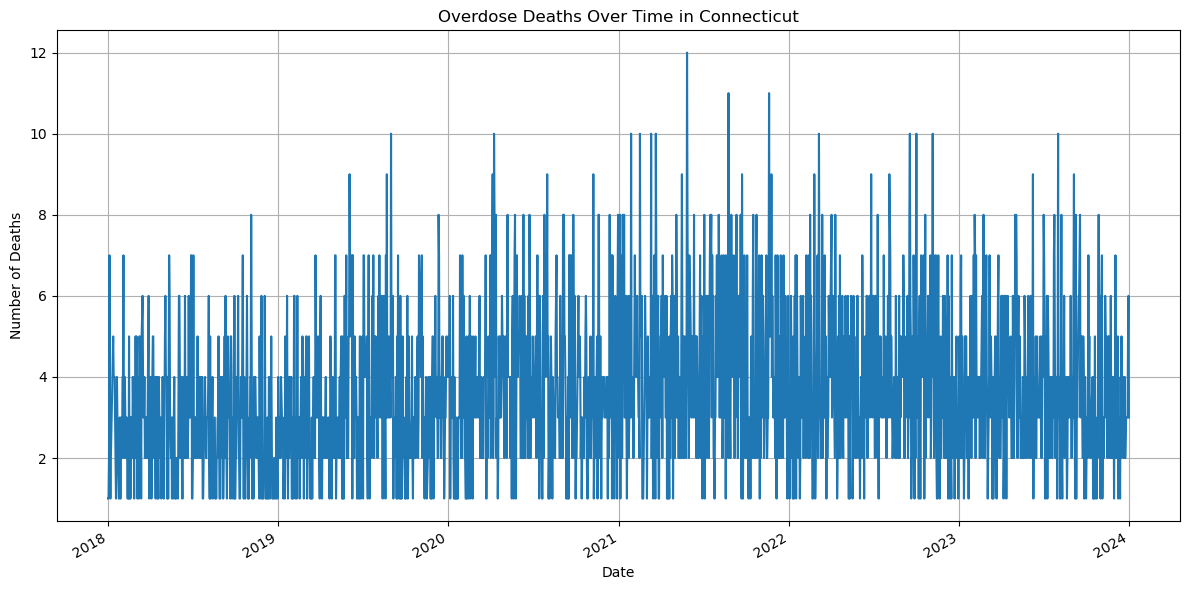

In [6]:
#Time Series Chart: Overdose deaths over time
import matplotlib.pyplot as plt

# Convert DateReported to datetime
df['DateReported'] = pd.to_datetime(df['DateReported'], errors='coerce')

# Group by date and count number of incidents
date_counts = df.groupby('DateReported').size()

# Plot
plt.figure(figsize=(12,6))
date_counts.plot()
plt.title("Overdose Deaths Over Time in Connecticut")
plt.xlabel("Date")
plt.ylabel("Number of Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()

Disregard the visualization above

C:\Users\Kehleboe\AppData\Local\Temp\ipykernel_51444\925380513.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=county_deaths, y='County', x='Deaths', palette='Reds_r')


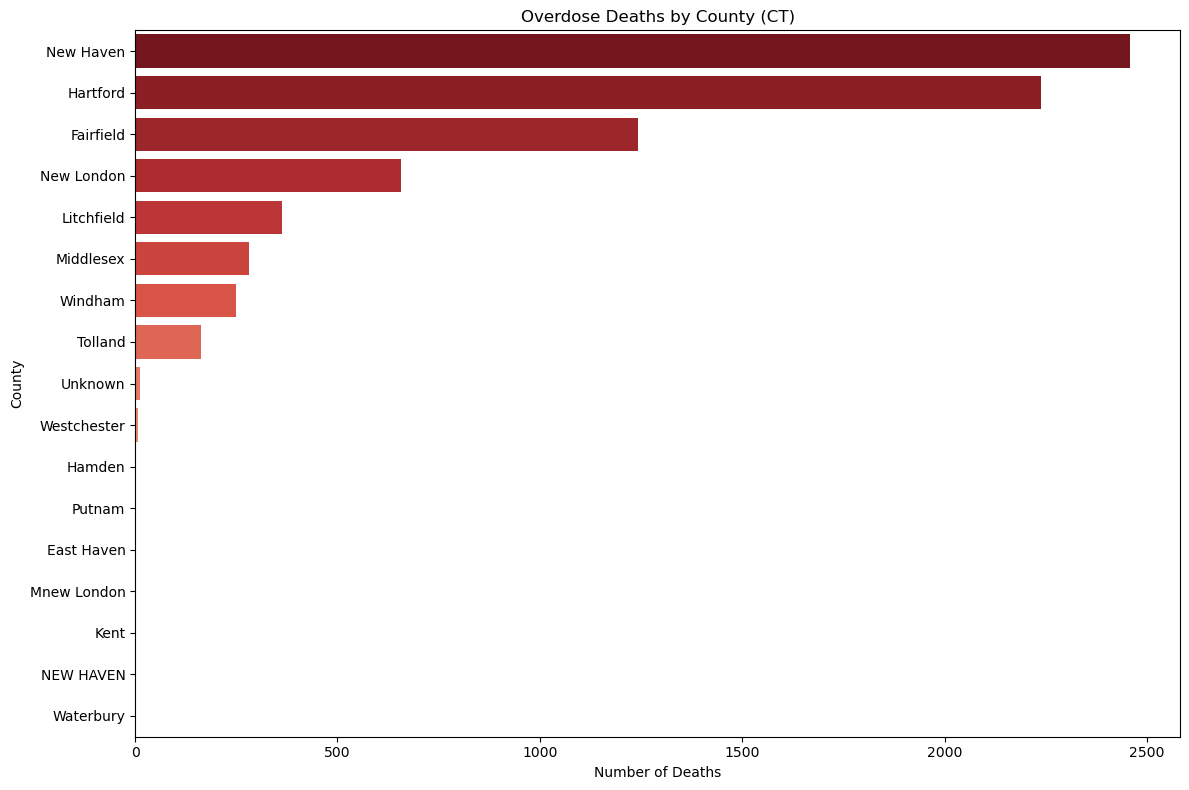

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of deaths per county
county_deaths = df['InjuryCounty'].value_counts().reset_index()
county_deaths.columns = ['County', 'Deaths']

# Plot as horizontal bar chart (heatmap style)
plt.figure(figsize=(12, 8))
sns.barplot(data=county_deaths, y='County', x='Deaths', palette='Reds_r')
plt.title("Overdose Deaths by County (CT)")
plt.xlabel("Number of Deaths")
plt.ylabel("County")
plt.tight_layout()
plt.show()

C:\Users\Kehleboe\AppData\Local\Temp\ipykernel_51444\925380513.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=county_deaths, y='County', x='Deaths', palette='Reds_r')


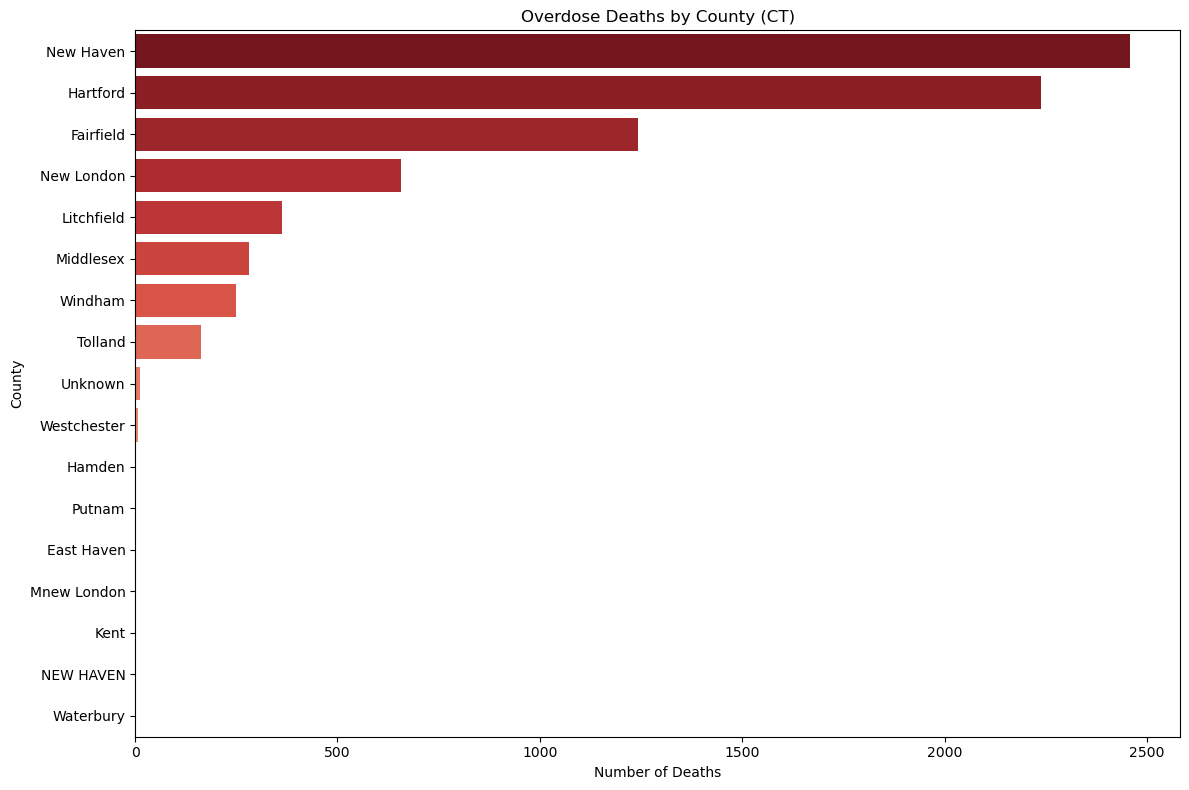

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of deaths per county
county_deaths = df['InjuryCounty'].value_counts().reset_index()
county_deaths.columns = ['County', 'Deaths']

# Plot as horizontal bar chart (heatmap style)
plt.figure(figsize=(12, 8))
sns.barplot(data=county_deaths, y='County', x='Deaths', palette='Reds_r')
plt.title("Overdose Deaths by County (CT)")
plt.xlabel("Number of Deaths")
plt.ylabel("County")
plt.tight_layout()
plt.show()

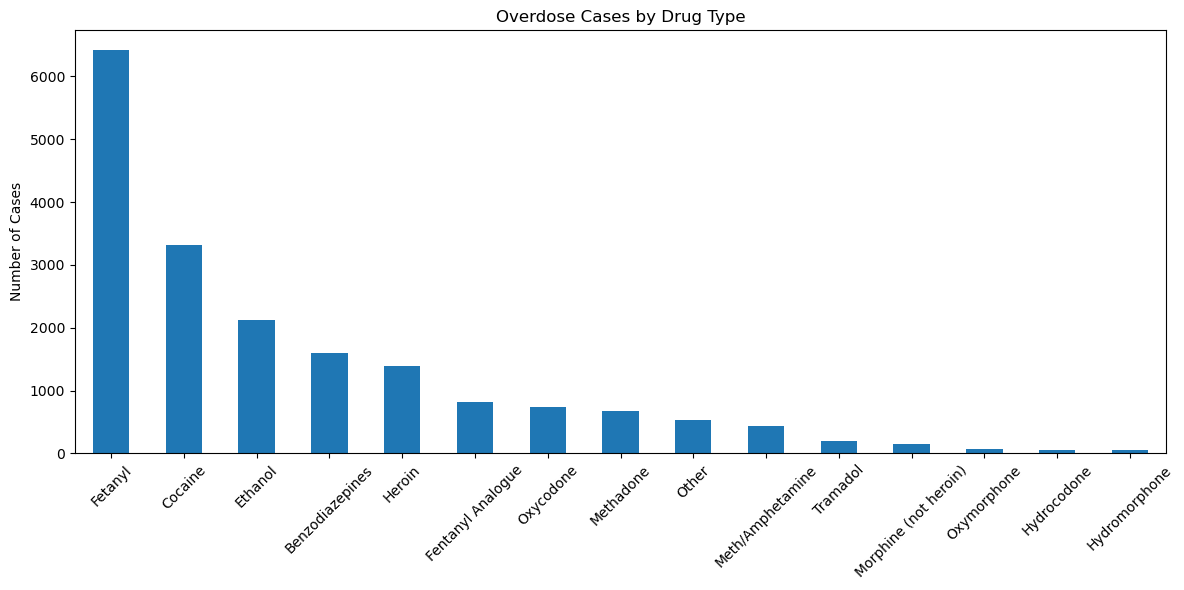

In [12]:
#Bar Chart by Drug Type — Carleigh
# Drug columns
drug_cols = df.columns[10:25]  # adjust as needed

# Sum for each drug
drug_counts = df[drug_cols].sum().sort_values(ascending=False)

# Plot
drug_counts.plot(kind='bar', figsize=(12,6))
plt.title("Overdose Cases by Drug Type")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

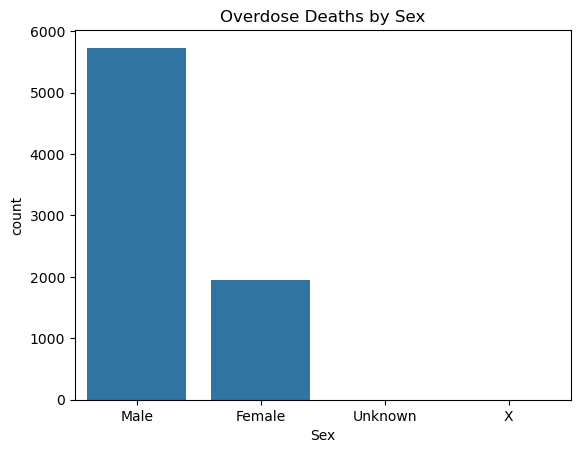

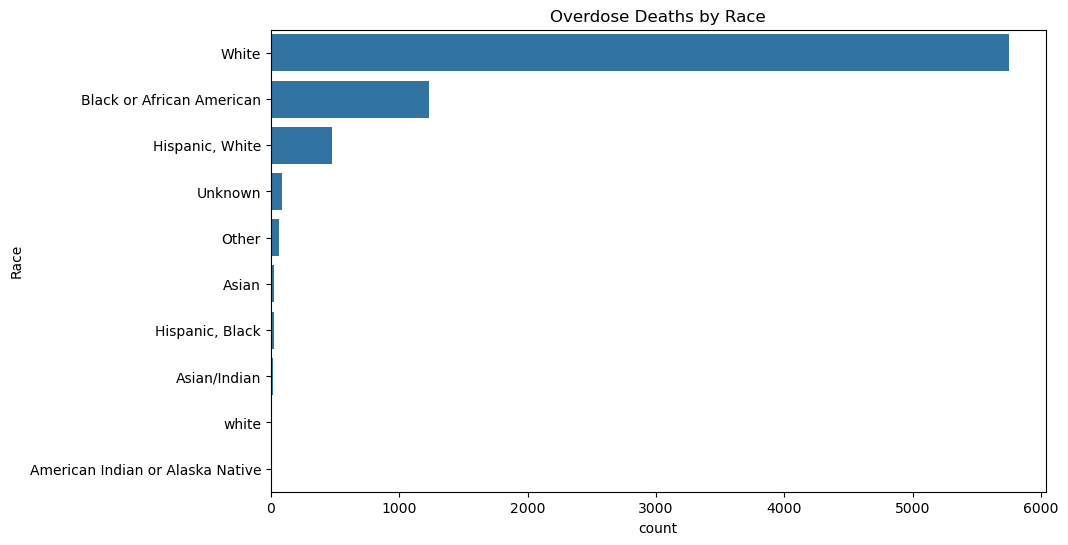

In [13]:
#Demographics
import seaborn as sns

# Sex distribution
sns.countplot(data=df, x='Sex')
plt.title("Overdose Deaths by Sex")
plt.show()

# Race distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Race', order=df['Race'].value_counts().index)
plt.title("Overdose Deaths by Race")
plt.show()
